**Проверяемые метрики:**

Оценка качества генерации текста — сложная задача. Мы будем использовать две метрики и смотреть на Loss модели:

*  Обучение (Train/Val Loss): Cross-Entropy Loss. Функция потерь, по которой модель обновляет веса. Желательно избежать переобучения и достичь результатов по Loss меньше ~1.5-2.0

* Главная бизнес-метрика: chrF (Character n-gram F-score). Оценивает совпадение сгенерированного текста с эталоном на уровне символов. Она идеально подходит для сленга, так как прощает ошибки в окончаниях (например, если модель выдала «кринж» вместо «кринжово»).

*  Вспомогательная метрика: BLEU-score. Классическая метрика машинного перевода. Посчитайте её для сравнения с chrF. Данная метрика легко считается и является бейзлайн-метрикой для любой задачи перевода.





In [10]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Данные

Итоговый датасет содержит 2 колонки: chunk и translate. В столбце chunk находится кусочек текста из классики. А в столбце translate – соответствующий ему перевод.


В данном датасете вы можете найти отрывки из следующих книг / сборников / произведений:

* А. П. Чехов — Собрание сочинений (рассказы и пьесы)

* А. С. Пушкин — повесть «Пиковая дама»

* И. С. Тургенев — роман «Отцы и дети»

* М. Ю. Лермонтов — роман «Герой нашего времени»

* Н. В. Гоголь — комедия «Ревизор»

* Н. В. Гоголь — поэма «Мёртвые души»

* А. Н. Островский — Собрание пьес (включая драму «Гроза»)

* Л. Н. Толстой — роман-эпопея «Война и мир»

* Ф. М. Достоевский — роман «Братья Карамазовы»

## Пояснение метрик



**BLEU-score** (Bilingual Evaluation Understudy)
Метрика основана на совпадении целых слов (униграмм) и их комбинаций (n-грамм: биграмм, триграмм и т.д.). Итоговый BLEU считается как геометрическое среднее точностей n-грамм, умноженное на штраф за краткость.

Формула:
$BLEU = BP \cdot \exp\left( \sum_{n=1}^{N} w_n \log p_n \right)$

Где:

$p_n$ — точность совпадения n-грамм (доля n-грамм из генерации, которые нашлись в эталоне).

$w_n$ — вес для $n$-граммы (обычно берут равномерные веса, например, для BLEU-4: $w_n = 0.25$).

$N$ — максимальная длина n-граммы (стандарт — 4).

$BP$ (Brevity Penalty) — штраф за краткость. Запрещает модели читерить, выдавая по одному правильному слову.

Формула штрафа за краткость ($BP$):
BP = \begin{cases} 1, & \text{если } c > r \\ \exp\left(1 - \frac{r}{c}\right), & \text{если } c \le r \end{cases}
Где $c$ — длина сгенерированного текста (candidate), $r$ — длина эталона (reference).



**chrF** (Character n-gram F-score)
В отличие от BLEU, chrF разбивает текст не на слова, а на символьные подстроки (от 1 до 6 символов) и считает по ним классическую F-меру.

Сначала считаются Precision и Recall для совпавших символьных кусочков:

$Precision (P) = \frac{\text{Кол-во совпавших символьных n-грамм}}{\text{Общее кол-во символьных n-грамм в генерации}}$


$Recall (R) = \frac{\text{Кол-во совпавших символьных n-грамм}}{\text{Общее кол-во символьных n-грамм в эталоне}}$

Затем вычисляется итоговая формула chrF (это стандартная $F_\beta$-мера):

$chrF = (1 + \beta^2) \frac{P \cdot R}{\beta^2 \cdot P + R}$

Где:

$\beta$ — параметр, определяющий баланс между точностью и полнотой.

В стандартной реализации (chrF2) используют $\beta = 2$, что дает больший вес Recall (полноте) — то есть алгоритму важнее, чтобы модель не потеряла смысл оригинала, даже если она добавила от себя лишние символы.

### Пример работы метрик

**Оригинал:** "Это было ужасно"

**Эталон**: "это было кринжово"

**Сгенерировано моделью:** "это был кринж"

----



BLEU разбивает текст по пробелам:

Слова эталона: ["это", "было", "кринжово"]

Слова модели: ["это", "был", "кринж"]

Для BLEU слова "было" и "был", а также "кринжово" и "кринж" — это абсолютно разные, никак не связанные слова (как "собака" и "самолет"). Совпало только одно слово: "это".


Шаг 1: Считаем совпадения (Precision для n-грамм)

1-граммы (отдельные слова): Из 3 сгенерированных слов в эталоне есть только одно — "это". $p_1 = 1 / 3 \approx 0.33$ (33%).

2-граммы (пары слов):
Пары модели: ["это был", "был кринж"].
Пары эталона: ["это было", "было кринжово"].
Совпадений нет! Точность $p_2 = 0 / 2 = 0$.

Шаг 2: Штраф за краткость (Brevity Penalty)
Длина генерации ($c=3$) равна длине эталона ($r=3$), поэтому модель не штрафуется за обрывание текста. $BP = 1$

Шаг 3: Итоговая формула BLEU

$$BLEU = BP \cdot \exp\left( \frac{1}{2} \log p_1 + \frac{1}{2} \log p_2 \right)$$

Так как точность биграмм $p_2 = 0$, логарифм нуля уходит в минус бесконечность, и весь BLEU обнуляется.

$$BLEU = 0$$

- - -

chrF нарезает текст на куски (например, по 4 символа, включая пробелы):

Куски эталона (14 штук):
"это_", "то_б", "о_бы", "_был", "было", "ыло_", "ло_к", "о_кр", "_кри", "крин", "ринж", "инжо", "нжов", "жово"

Куски модели (10 штук):
"это_", "то_б", "о_бы", "_был", "был_", "ыл_к", "л_кр", "_кри", "крин", "ринж"

Шаг 1: Ищем совпадения
Алгоритм сравнивает два списка и находит 7 идеальных совпадений:
"это_", "то_б", "о_бы", "_был", "_кри", "крин", "ринж". Корень слова и начало предложения схвачены верно!

Алгоритм видит, что куски "это ", "то б", " был", " кри", "крин", "ринж" совпали


Шаг 2: Считаем Точность (Precision) и Полноту (Recall)

Precision ($P$): Доля правильных кусков среди всех сгенерированных.
$P = 7 / 10 = 0.70$ (70% того, что выдала модель — верно).

Recall ($R$): Доля кусков эталона, которые смогла покрыть модель.
$R = 7 / 14 = 0.50$ (Модель восстановила 50% от оригинальной строки).

Шаг 3: Итоговая формула (F2-score)
chrF по умолчанию использует $\beta = 2$, что дает Полноте в 2 раза больший вес, чем Точности (важнее не потерять смысл, чем не наделать опечаток).

$$chrF = 5 \frac{P \cdot R}{4p+R}$$

Подставляем наши числа и получаем ответ:

$$chrF = 5 \frac{0.7 \cdot 0.5}{4\cdot 0.7 + 0.5} \approx 0.53$$

In [11]:
import sys
import sentencepiece

print(sys.executable)
print(sentencepiece.__version__)

/usr/bin/python3
0.2.1


### Код метрик

In [12]:
import math
from collections import Counter

def get_word_ngrams(tokens: list, n: int) -> list:
    """
    Разбивает список токенов на n-граммы уровня слов.
    """
    return [tuple(tokens[i : i + n]) for i in range(len(tokens) - n + 1)]


def get_char_ngrams(text: str, n: int) -> list:
    """
    Разбивает строку на n-граммы уровня символов.
    """
    return [text[i : i + n] for i in range(len(text) - n + 1)]


Покажем как работает базовое разбиение на n-граммы: посимвольные и по-"подсловные".

In [13]:
get_word_ngrams(["я", "тебя", "крашу", "чееел"], 2)

[('я', 'тебя'), ('тебя', 'крашу'), ('крашу', 'чееел')]

In [14]:
get_char_ngrams("кринж", 3)

['кри', 'рин', 'инж']

Вычислим теперь наши метрики для двух наших текстов

In [15]:
def bleu_single(reference: str, candidate: str, max_n: int = 4) -> float:
    """
    Вычисляет BLEU-score для одной пары (reference, candidate).
    Шаги:
      1. Токенизация — разбиение по пробелам
      2. Clipped precision — для каждого n считаем долю n-грамм генерации,
         которые есть в эталоне; одна n-грамма эталона не засчитывается дважды
      3. Add-1 сглаживание — (matches + 1) / (total + 1), чтобы избежать log(0)
         при нулевых совпадениях в высших n-граммах
      4. Brevity Penalty — штраф exp(1 - r/c), если генерация короче эталона

    Args:
        reference : эталонный текст (строка)
        candidate : сгенерированный текст (строка)
        max_n     : максимальный порядок n-граммы (по умолчанию 4 → BLEU-4)

    Returns:
        float в диапазоне [0.0, 1.0]
    """
    ref_tokens  = reference.lower().split()
    cand_tokens = candidate.lower().split()

    c = len(cand_tokens)
    r = len(ref_tokens)

    if c == 0:
        return 0.0

    # Штрафуем только за генерацию короче эталона; длиннее — штрафа нет
    bp  = 1.0 if c > r else math.exp(1 - r / c)
    w_n = 1.0 / max_n
    log_avg = 0.0

    for n in range(1, max_n + 1):
        ref_ngrams  = Counter(get_word_ngrams(ref_tokens, n))
        cand_ngrams = Counter(get_word_ngrams(cand_tokens, n))

        # Clipped: не даём модели накручивать счёт повторами одной n-граммы
        matches = sum(min(cnt, ref_ngrams[ngram]) for ngram, cnt in cand_ngrams.items())
        total   = max(c - n + 1, 1)  # floor=1, если предложение короче n

        # Нет совпадений даже на уровне слов — тексты семантически разные
        if n == 1 and matches == 0:
            return 0.0

        p_n      = (matches + 1) / (total + 1)
        log_avg += w_n * math.log(p_n)

    return bp * math.exp(log_avg)


def chrf_single(reference: str, candidate: str, max_n: int = 6, beta: float = 2.0) -> float:
    """
    Вычисляет chrF-score для одной пары (reference, candidate).

    Шаги:
      1. Разбить оба текста на символьные n-граммы (для n от 1 до max_n)
      2. Для каждого n посчитать Precision и Recall по совпавшим кускам
      3. Усреднить Precision и Recall по всем n
      4. Итог: F_beta-мера из усредненных P и R

    Args:
        reference  : эталонный текст (строка)
        candidate  : сгенерированный текст (строка)
        max_n      : максимальный порядок символьной n-граммы (по умолчанию 6)
        beta       : вес Recall относительно Precision (по умолчанию 2.0 -> chrF2)

    Returns:
        float в диапазоне [0.0, 1.0]
    """
    if len(candidate) == 0 or len(reference) == 0:
        return 0.0

    total_precision = 0.0
    total_recall    = 0.0

    for n in range(1, max_n + 1):
        ref_ngrams  = Counter(get_char_ngrams(reference, n))
        cand_ngrams = Counter(get_char_ngrams(candidate, n))

        # Считаем совпавшие символьные куски
        matches = sum(
            min(count, ref_ngrams.get(ngram, 0))
            for ngram, count in cand_ngrams.items()
        )

        total_cand = sum(cand_ngrams.values())  # знаменатель Precision
        total_ref  = sum(ref_ngrams.values())   # знаменатель Recall

        if total_cand > 0:
            total_precision += (matches + 1)/ (total_cand + 1)
        if total_ref > 0:
            total_recall += matches / total_ref

    # Усредняем Precision и Recall по всем порядкам n
    avg_p = total_precision / max_n
    avg_r = total_recall    / max_n

    if avg_p + avg_r == 0:
        return 0.0

    # считаем f-бета меру
    chrf = (1 + beta**2) * (avg_p * avg_r) / (beta**2 * avg_p + avg_r)
    return chrf




А теперь с помощью функций выше напишем вычисление метрик для массива текстов. Мы используем такой же интерфейс как у `sci-kit-learn`, где есть необходимо передать `y_true` и `y_pred`

In [16]:
def compute_bleu(y_true: list, y_pred: list, max_n: int = 4) -> float:
    """Считает средний BLEU по всем парам датасета."""
    scores = [bleu_single(ref, cand, max_n) for ref, cand in zip(y_true, y_pred)]
    return sum(scores) / len(scores)


def compute_chrf(y_true: list, y_pred: list, max_n: int = 6, beta: float = 2.0) -> float:
    """Считает средний chrF по всем парам датасета."""
    scores = [chrf_single(ref, cand, max_n, beta) for ref, cand in zip(y_true, y_pred)]
    return sum(scores) / len(scores)


А здесь мы посмотрим на примеры работы этих метрик с помощью assert-ов

In [17]:

# ──────────────── ТЕСТ 1 ────────────────
# Идеальное совпадение: предсказание == эталон
# Ожидание: BLEU = 1.0, chrF = 1.0
ref = "этот анк выдал жесткую базу"
assert bleu_single(ref, ref) == 1.0, \
    "ТЕСТ 1 BLEU: При идеальном совпадении BLEU должен быть 1.0"
assert abs(chrf_single(ref, ref) - 1.0) < 1e-9, \
    " ТЕСТ 1 chrF: При идеальном совпадении chrF должен быть 1.0"
print("Тест 1 пройден: Идеальное совпадение → BLEU=1.0, chrF=1.0")

# ──────────────── ТЕСТ 2 ────────────────
# Пустая генерация: candidate = ""
# Ожидание: BLEU = 0.0, chrF = 0.0
ref = "он буквально вкрашился в неё"
assert bleu_single(ref, "") == 0.0, \
    " ТЕСТ 2 BLEU: Пустая генерация должна давать 0.0"
assert chrf_single(ref, "") == 0.0, \
    " ТЕСТ 2 chrF: Пустая генерация должна давать 0.0"
print("Тест 2 пройден: Пустая генерация → BLEU=0.0, chrF=0.0")

# ──────────────── ТЕСТ 3 ────────────────
# Полностью разные тексты
# Ожидание: BLEU = 0.0, chrF близко к 0
ref  = "служить бы рад прислуживаться тошно"
cand = "икс игрек зет фу бар"
assert bleu_single(ref, cand) == 0.0, \
    " ТЕСТ 3 BLEU: Полностью разные тексты → BLEU должен быть 0.0"
assert chrf_single(ref, cand) < 0.1, \
    " ТЕСТ 3 chrF: Полностью разные тексты → chrF должен быть близок к 0"
print(" Тест 3 пройден: Полностью разные тексты → BLEU=0.0, chrF≈0")

# ──────────────── ТЕСТ 4 ────────────────
# Ключевой тест: chrF > BLEU при морфологическом совпадении
# "кринж" vs "кринжово" — разные слова для BLEU, но похожие символьно для chrF
ref  = "это было кринжово"
cand = "это было кринж"
bleu_score = bleu_single(ref, cand)
chrf_score = chrf_single(ref, cand)
assert chrf_score > bleu_score, \
    f" ТЕСТ 4: chrF ({chrf_score:.3f}) должен быть > BLEU ({bleu_score:.3f}) при морфологических различиях!"
print(f" Тест 4 пройден: chrF ({chrf_score:.3f}) > BLEU ({bleu_score:.3f}) — chrF лучше для русской морфологии!")

# ──────────────── ТЕСТ 5 ────────────────
# Частичное совпадение: значения должны быть строго в диапазоне (0, 1)
ref  = "базаров выдал жесткую базу и ливнул"
cand = "базаров выдал базу и просто ушел"
bleu_score = bleu_single(ref, cand)
chrf_score = chrf_single(ref, cand)
assert 0.0 < bleu_score < 1.0, \
    f" ТЕСТ 5 BLEU: При частичном совпадении BLEU должен быть в (0, 1), получили {bleu_score:.3f}"
assert 0.0 < chrf_score < 1.0, \
    f" ТЕСТ 5 chrF: При частичном совпадении chrF должен быть в (0, 1), получили {chrf_score:.3f}"
print(f" Тест 5 пройден: Частичное совпадение → BLEU={bleu_score:.3f}, chrF={chrf_score:.3f}")

# ──────────────── ТЕСТ 6 ────────────────
# Тест усреднения по датасету
y_true = ["этот скуф выдал базу",     "она ливнула с вписки"]
y_pred = ["этот скуф выдал базу",     "она ливнула с вписки"]  # идеальные предсказания
assert compute_bleu(y_true, y_pred) == 1.0, \
    " ТЕСТ 6 BLEU: Усредненный BLEU по идеальным парам должен быть 1.0"
assert abs(compute_chrf(y_true, y_pred) - 1.0) < 1e-9, \
    " ТЕСТ 6 chrF: Усредненный chrF по идеальным парам должен быть 1.0"
print(" Тест 6 пройден: Усреднение по датасету работает корректно!")


Тест 1 пройден: Идеальное совпадение → BLEU=1.0, chrF=1.0
Тест 2 пройден: Пустая генерация → BLEU=0.0, chrF=0.0
 Тест 3 пройден: Полностью разные тексты → BLEU=0.0, chrF≈0
 Тест 4 пройден: chrF (0.825) > BLEU (0.595) — chrF лучше для русской морфологии!
 Тест 5 пройден: Частичное совпадение → BLEU=0.366, chrF=0.560
 Тест 6 пройден: Усреднение по датасету работает корректно!


In [18]:
import sacrebleu

def bleu_single(reference: str, candidate: str, max_n: int = 4) -> float:
    """
    BLEU для одной пары (sentence-level) через sacrebleu.
    Возвращает значение в диапазоне [0, 1].
    """
    if not candidate.strip():
        return 0.0

    bleu = sacrebleu.sentence_bleu(
        candidate,
        [reference],
        smooth_method="none",
        use_effective_order=False
    )
    return bleu.score / 100.0


def chrf_single(reference: str, candidate: str, max_n: int = 6, beta: float = 2.0) -> float:
    """
    chrF для одной пары (sentence-level) через sacrebleu.
    Возвращает значение в диапазоне [0, 1].
    """
    if not candidate.strip():
        return 0.0

    chrf = sacrebleu.sentence_chrf(
        candidate,
        [reference],
        char_order=4,
        beta=beta
    )
    return chrf.score / 100.0


def compute_bleu(y_true: list, y_pred: list, max_n: int = 4) -> float:
    """
    Corpus-level BLEU через sacrebleu (корректный стандартный способ).
    Возвращает значение в диапазоне [0, 1].
    """
    if not y_true:
        return 0.0

    bleu = sacrebleu.corpus_bleu(
        y_pred,
        [y_true],
        smooth_method="none",
        use_effective_order=False
    )
    return bleu.score / 100.0


def compute_chrf(y_true: list, y_pred: list, max_n: int = 6, beta: float = 2.0) -> float:
    """
    Corpus-level chrF через sacrebleu.
    Возвращает значение в диапазоне [0, 1].
    """
    if not y_true:
        return 0.0

    chrf = sacrebleu.corpus_chrf(
        y_pred,
        [y_true],
        char_order=max_n,
        beta=beta
    )
    return chrf.score / 100.0

In [19]:
bleu_single("это было кринжово", "это было кринж")
chrf_single("это было кринжово", "это было кринж")

0.8126024560697133

## Решение

In [20]:
import numpy as np
import pandas as pd
df = pd.read_csv("data/dataset.csv")
print(df.columns)

Index(['chunk', 'translate'], dtype='object')


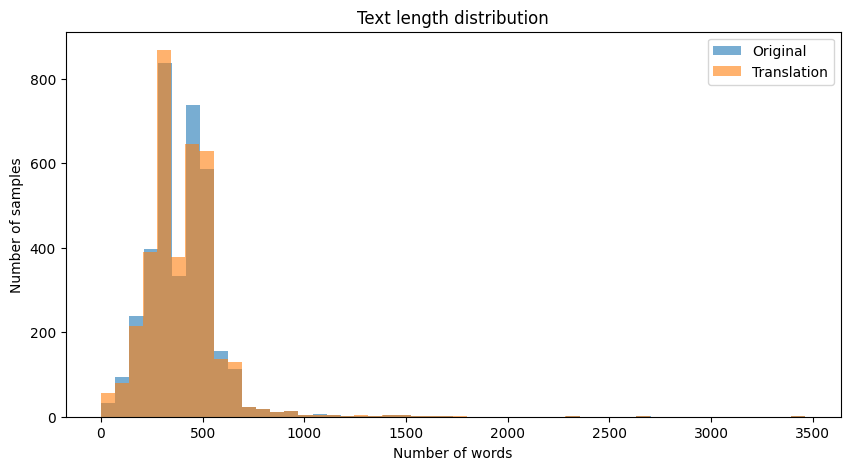

In [21]:
import matplotlib.pyplot as plt

df["chunk"] = df["chunk"].fillna("").astype(str)
df["translate"] = df["translate"].fillna("").astype(str)

df["chunk_len_words"] = df["chunk"].str.split().apply(len)
df["translate_len_words"] = df["translate"].str.split().apply(len)

plt.figure(figsize=(10, 5))
plt.hist(df["chunk_len_words"], bins=50, alpha=0.6, label="Original")
plt.hist(df["translate_len_words"], bins=50, alpha=0.6, label="Translation")
plt.xlabel("Number of words")
plt.ylabel("Number of samples")
plt.title("Text length distribution")
plt.legend()
plt.show()

Тут я чищу датасет по такой логике: удаляю NaN, все привожу к строкам, убираю пробелы и лишние дубли, выкидываю пустые строки, так же я удаляю пары, которые похожи друг на друга хотябы на 90%, такое удаление дало мне значительный прирост в обучении

In [22]:
import re
import difflib

df = df[["chunk", "translate"]].dropna().copy()
df["chunk"] = df["chunk"].astype(str).str.strip()
df["translate"] = df["translate"].astype(str).str.strip()
df = df.drop_duplicates(subset=["chunk", "translate"]).copy()
df = df[['chunk', 'translate']].copy()
df['chunk'] = df['chunk'].astype(str).str.replace(r'\s+', ' ', regex=True).str.strip()
df['translate'] = df['translate'].astype(str).str.replace(r'\s+', ' ', regex=True).str.strip()
df = df[(df['chunk'] != '') & (df['translate'] != '')].drop_duplicates().reset_index(drop=True)

def normalize_text(text):
    text = str(text).lower().strip()
    text = re.sub(r"\s+", " ", text)
    return text

df["sim"] = [difflib.SequenceMatcher(None, normalize_text(src), normalize_text(tgt)).ratio() for src, tgt in zip(df["chunk"], df["translate"])]

df = df[df["sim"] < 0.9].reset_index(drop=True)




In [23]:
prepared_rows = []

for _, row in df.iterrows():
    source = row["chunk"]
    target = row["translate"]

    prepared_rows.append({
        "chunk": source,
        "translate": target
    })

prepared_df = pd.DataFrame(prepared_rows).drop_duplicates().reset_index(drop=True)

In [24]:
from transformers import T5Tokenizer, AutoModelForSeq2SeqLM

tokenizer = T5Tokenizer.from_pretrained("ai-forever/ruT5-base")
model = AutoModelForSeq2SeqLM.from_pretrained("ai-forever/ruT5-base")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/1.00M [00:00<?, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/892M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/260 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Начинаю работать с моделькой, путем экспирементов и потраченных нервов, я пришел к выводу, что лучшая модель ruT5-base

In [25]:
model.to("cuda")

model.safetensors:   0%|          | 0.00/892M [00:00<?, ?B/s]

T5ForConditionalGeneration(
  (shared): Embedding(32128, 768)
  (encoder): T5Stack(
    (embed_tokens): Embedding(32128, 768)
    (block): ModuleList(
      (0): T5Block(
        (layer): ModuleList(
          (0): T5LayerSelfAttention(
            (SelfAttention): T5Attention(
              (q): Linear(in_features=768, out_features=768, bias=False)
              (k): Linear(in_features=768, out_features=768, bias=False)
              (v): Linear(in_features=768, out_features=768, bias=False)
              (o): Linear(in_features=768, out_features=768, bias=False)
              (relative_attention_bias): Embedding(32, 12)
            )
            (layer_norm): T5LayerNorm()
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (1): T5LayerFF(
            (DenseReluDense): T5DenseActDense(
              (wi): Linear(in_features=768, out_features=3072, bias=False)
              (wo): Linear(in_features=3072, out_features=768, bias=False)
              (dropout): Dro

Это одна из самых важных частей. Я режу датасет по предложения по 512 токенов, такой способ я выбрал тоже путем экспериментов. После удаляю дубликаты

In [26]:
import math

PROMPT = "переведи со старорусского на зумерский: "

def text_to_ids(text):
    return tokenizer(text, add_special_tokens=False)["input_ids"]

PROMPT_TOKENS = len(text_to_ids(PROMPT))
SOURCE_LIMIT = 512 - PROMPT_TOKENS
TARGET_LIMIT = 512

def ids_to_text(token_ids):
    return tokenizer.decode(token_ids, skip_special_tokens=True, clean_up_tokenization_spaces=False,).strip()

def split_translation_pair(
    source_text,
    target_text
    ):
    source_ids = text_to_ids(source_text)
    target_ids = text_to_ids(target_text)

    if not source_ids or not target_ids:
        return []

    prt = max(1, math.ceil(len(source_ids) / SOURCE_LIMIT), math.ceil(len(target_ids) / TARGET_LIMIT))

    source_chunk_size = math.ceil(len(source_ids) / prt)
    target_chunk_size = math.ceil(len(target_ids) / prt)

    result = []

    for part_idx in range(prt):
        source_start = part_idx * source_chunk_size
        source_end = (part_idx + 1) * source_chunk_size
        target_start = part_idx * target_chunk_size
        target_end = (part_idx + 1) * target_chunk_size

        source_slice = source_ids[source_start:source_end]
        target_slice = target_ids[target_start:target_end]

        if not source_slice or not target_slice:
            continue

        source_chunk = ids_to_text(source_slice)
        target_chunk = ids_to_text(target_slice)

        if source_chunk and target_chunk:
            result.append({"chunk": source_chunk,"translate": target_chunk,})

    return result


split_rows = []

for _, sample in df.iterrows():
    split_rows.extend(split_translation_pair(sample["chunk"], sample["translate"]))

prepared_df = pd.DataFrame(split_rows).drop_duplicates().reset_index(drop=True)



In [27]:
from sklearn.model_selection import train_test_split
from datasets import Dataset, DatasetDict

KEK=67

X = prepared_df["chunk"].copy()
y = prepared_df["translate"].copy()

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=KEK,
    shuffle=True
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=KEK,
    shuffle=True
)

train_df = pd.DataFrame({
    "chunk": X_train.reset_index(drop=True),
    "translate": y_train.reset_index(drop=True)
})

val_df = pd.DataFrame({
    "chunk": X_val.reset_index(drop=True),
    "translate": y_val.reset_index(drop=True)
})

test_df = pd.DataFrame({
    "chunk": X_test.reset_index(drop=True),
    "translate": y_test.reset_index(drop=True)
})

train_ds = Dataset.from_pandas(train_df, preserve_index=False)
val_ds = Dataset.from_pandas(val_df, preserve_index=False)
test_ds = Dataset.from_pandas(test_df, preserve_index=False)


In [28]:
dataset = DatasetDict({
    "train": train_ds,
    "validation": val_ds,
    "test": test_ds
})

Теперь просто все превращаю в токены, чтобы моделька меня поняла

In [29]:
def build_all_prompt(text):
    return PROMPT + text

def preprocess_batch(batch):
    source_texts = []
    for text in batch["chunk"]:
        source_texts.append(build_all_prompt(text))

    model_inputs = tokenizer(
        source_texts,
        max_length=512,
        truncation=True,
    )

    labels = tokenizer(
        text_target=batch["translate"],
        max_length=512,
        truncation=True,
    )

    model_inputs["labels"] = labels["input_ids"]
    return model_inputs



In [30]:
from transformers import (
    DataCollatorForSeq2Seq,
    Seq2SeqTrainingArguments,
    Seq2SeqTrainer,
)

tokenized_dataset = dataset.map(
    preprocess_batch,
    batched=True,
    remove_columns=["chunk", "translate"],
)

data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model,
)
training_args = Seq2SeqTrainingArguments(
    output_dir="zoomer2",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=50,
    learning_rate=1e-4,
    warmup_steps=50,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    weight_decay=0.01,
    num_train_epochs=8,
    predict_with_generate=True,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    save_total_limit=2,
    report_to="none",
    fp16=True,
)
trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    processing_class=tokenizer,
    data_collator=data_collator,
)




Map:   0%|          | 0/4370 [00:00<?, ? examples/s]

Map:   0%|          | 0/546 [00:00<?, ? examples/s]

Map:   0%|          | 0/547 [00:00<?, ? examples/s]

In [31]:
trainer.train()

Epoch,Training Loss,Validation Loss
1,0.871446,0.675625
2,0.724149,0.602754
3,0.558944,0.557849
4,0.515581,0.542261
5,0.531933,0.542908
6,0.436304,0.538547
7,0.386564,0.538808
8,0.346253,0.541455


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=8744, training_loss=0.6083315026291117, metrics={'train_runtime': 5442.0961, 'train_samples_per_second': 6.424, 'train_steps_per_second': 1.607, 'total_flos': 2.040429526974259e+16, 'train_loss': 0.6083315026291117, 'epoch': 8.0})

In [32]:
trainer.save_model("zoomer2_final")
tokenizer.save_pretrained("zoomer2_final")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('zoomer2_final/tokenizer_config.json', 'zoomer2_final/tokenizer.json')

## Итог



Функция для перевода текста на основе обученной модели

In [33]:

import torch
def translate(old_text):
    model.eval()
    source_text = build_all_prompt(old_text)

    inputs = tokenizer(
        source_text,
        return_tensors="pt",
        max_length=512,
        truncation=True,
    )

    input_ids = inputs["input_ids"].to(model.device)
    attention_mask = inputs["attention_mask"].to(model.device)

    with torch.no_grad():
        generated_ids = model.generate(
            input_ids=input_ids,
            attention_mask=attention_mask,
            max_new_tokens=128,
            num_beams=4, #выбирает лучшие из 4
            do_sample=False,
            early_stopping=True,
            no_repeat_ngram_size=2,
            repetition_penalty=1.2, #штрафую за повторы, с этим было больше всего проблем, но я справился!!!!
            length_penalty=1.0,

        )

    new_text = tokenizer.decode(
        generated_ids[0],
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False,
    ).strip()

    return new_text

Посчитаем среднее значение метрик и функции потерь на объектах из датасета

In [34]:
import torch
split = dataset["test"]

references = []
predictions = []
loss_values = []

model.eval()

for sample in split:
    source_text = sample["chunk"]
    target_text = sample["translate"]

    predicted_text = translate(source_text)

    predictions.append(predicted_text)
    references.append(target_text)

    model_inputs = tokenizer(
        build_all_prompt(source_text),
        return_tensors="pt",
        max_length=512,
        truncation=True,
    )

    labels = tokenizer(
        text_target=target_text,
        return_tensors="pt",
        max_length=512,
        truncation=True,
    )["input_ids"]

    model_inputs = {k: v.to(model.device) for k, v in model_inputs.items()}
    labels = labels.to(model.device)

    with torch.no_grad():
        outputs = model(**model_inputs, labels=labels)
        loss_values.append(outputs.loss.item())



Считаю метрики

In [35]:
cross_entropy_loss = sum(loss_values) / len(loss_values)
chr_f_metric = compute_chrf(references, predictions)
bleu_metric = compute_bleu(references, predictions)

print(f"Cross-Entropy Loss: {cross_entropy_loss:.4f}")
print(f"chrF: {chr_f_metric:.4f}")
print(f"BLEU: {bleu_metric:.4f}")

Cross-Entropy Loss: 0.5277
chrF: 0.3479
BLEU: 0.1185


In [36]:

example = "Позор и отродье"

translated_example = translate(example)
print(example)
print(translated_example)


chr_f_metric = chrf_single("Кринж и ужас", translate(example))
bleu_metric = bleu_single("Кринж и ужас", translate(example))
print(f"Chr-F: {chr_f_metric}\nBLEU: {bleu_metric}\n\nПеревод: {translated_example}")

Позор и отродье
Позор и отродье — это полный зашквар.


Chr-F: 0.08938130533250979
BLEU: 0.0

Перевод: Позор и отродье — это полный зашквар.
